# PF-5039: Semana 01 - Práctica Asincrónica Desafío Avanzado
## Simulación de Aliasing Espacial, Filtro Antialiasing y Evaluación de PSNR en Retinografía

**Estudiante:** _____________________ **Carné:** ____________

---
### Requerimientos del Desafío:
En esta práctica autónoma de 1 hora, estudiará en detalle cómo prevenir el fenómeno de Aliasing/Moiré en imágenes médicas de alta densidad cromática.

In [29]:
import sys
print(sys.executable)

c:\Users\Docente\Desktop\curso analisis imagenes\analisis-imagenes\.venv\Scripts\python.exe


--- 
### Parte A: Simulación de Aliasing en una Grilla Sinusoidal Sintética
1. Genere una matriz de $512 \times 512$ píxeles representando la función matemática $f(x, y) = \sin(2\pi f_0 x) + \sin(2\pi f_0 y)$ con $f_0 = 15$.
2. Aplique un submuestreo por un factor de escala $S = 4$ mediante dos métodos:
   - **Método 1 (Submuestreo Directo sin Filtrado):** Tome cada $S$-ésimo píxel directo de la matriz (`pattern[::S, ::S]`).
   - **Método 2 (Submuestreo Filtrado Antialiasing):** Aplique un filtro pasa-bajo Gaussiano (`cv2.GaussianBlur`) con $\sigma = S/2 = 2.0$ y luego submuestree.
3. Grafique los 3 mapas de intensidad en paralelo e interpete la presencia de patrones Moiré.

**Interpretación:** El submuestreo directo produce aliasing porque toma píxeles sin eliminar las frecuencias espaciales altas. Esto puede generar patrones Moiré, visibles como bandas u oscilaciones falsas en el mapa reducido. En cambio, el filtro Gaussiano suaviza la señal antes de reducirla y atenúa las frecuencias que podrían exceder el límite de Nyquist. Por ello, el mapa filtrado presenta menos patrones Moiré y una intensidad más uniforme, aunque con cierta pérdida de nitidez y contraste.

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la grilla y de la función sinusoidal
N = 512
f0 = 15
x = np.arange(N) / N
y = np.arange(N) / N
X, Y = np.meshgrid(x, y)

# Matriz 512 x 512: f(x, y) = sin(2*pi*f0*x) + sin(2*pi*f0*y)
pattern = np.sin(2 * np.pi * f0 * X) + np.sin(2 * np.pi * f0 * Y)

print(f"Dimensiones de la matriz: {pattern.shape}")
print(f"Rango de valores: [{pattern.min():.3f}, {pattern.max():.3f}]")

Dimensiones de la matriz: (512, 512)
Rango de valores: [-2.000, 2.000]


Dimensiones del submuestreo directo: (128, 128)
Dimensiones del submuestreo Gaussiano: (128, 128)


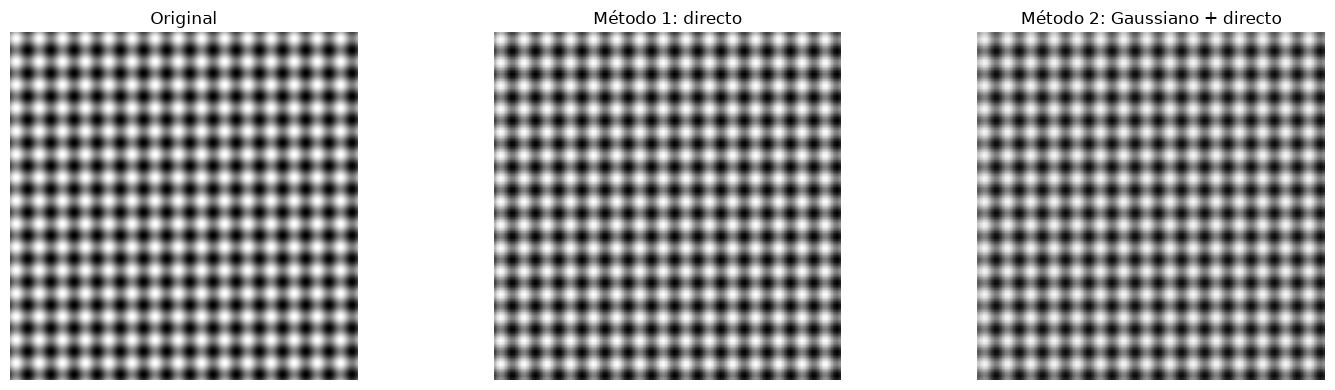

In [31]:
# Factor de submuestreo y filtro antialiasing
S = 4
sigma = S / 2

# Método 1: submuestreo directo, sin filtrado
pattern_directo = pattern[::S, ::S]

# Método 2: filtro pasa-bajo Gaussiano seguido de submuestreo
pattern_filtrado = cv2.GaussianBlur(pattern, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
pattern_gaussiano = pattern_filtrado[::S, ::S]

print(f"Dimensiones del submuestreo directo: {pattern_directo.shape}")
print(f"Dimensiones del submuestreo Gaussiano: {pattern_gaussiano.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
imagenes = [pattern, pattern_directo, pattern_gaussiano]
titulos = ["Original", "Método 1: directo", "Método 2: Gaussiano + directo"]

for ax, imagen, titulo in zip(axes, imagenes, titulos):
    ax.imshow(imagen, cmap="gray", vmin=-2, vmax=2)
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
plt.show()

--- 
### Parte B: Evaluación Cuantitativa de PSNR en Submuestreo de Retinografía
1. Cargue la imagen médica `retinografia_microaneurismas.png` ($512 \times 512$).
2. Reduzca la resolución espacial a $128 \times 128$ ($S=4$) mediante submuestreo directo y submuestreo con filtro Gaussiano.
3. Vuelva a escalar ambas imágenes reducidas a la dimensión original de $512 \times 512$ (`cv2.INTER_NEAREST`) para poder compararlas matriz a matriz con la original.
4. Calcule la métrica PSNR (dB) para ambos métodos y concluya cuál preserva mejor la fidelidad estructural de la vascularización retiniana.

In [ ]:
from pathlib import Path

ruta_imagen = Path("imagenes") / "retinografia_microaneurismas.png"
imagen_retinografia = cv2.imread(str(ruta_imagen), cv2.IMREAD_GRAYSCALE)

if imagen_retinografia is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {ruta_imagen}")

print(f"Ruta de la imagen: {ruta_imagen}")
print(f"Dimensiones de la imagen: {imagen_retinografia.shape}")
print(f"Tipo de datos: {imagen_retinografia.dtype}")

plt.figure(figsize=(6, 6))
plt.imshow(imagen_retinografia, cmap="gray")
plt.title("Retinografía con microaneurismas")
plt.axis("off")
plt.show()